In [1]:
# all import statements
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
BACKPROP_TRAINING_PATH = "/home/apassi1/bottleneck_training_runs/"

In [2]:
def load_acc(model_label,ckpt_epoch):
    f_load = f'{BACKPROP_TRAINING_PATH}/{model_label}/checkpoint-{ckpt_epoch}/trainer_state.json'
    with open(f_load,'r') as f:
        trainer_state = json.load(f)
        eval_accuracy=trainer_state['log_history'][-1]['eval_accuracy']
    return eval_accuracy

In [3]:
# Define the color scheme
classification_palette = sns.color_palette("autumn", 2)  # Generates two colors
resnet_color = "red"  # Explicitly set ResNet to red
scattering_color = classification_palette[0]  # First color for Random scattering network
pca_scattering_color = classification_palette[1]  # Second color for PCA trained scattering network

In [4]:
# # First model: ResNet
# model_label = "lr0.001_resnet_baselineTrue"
# folder_path = f'{BACKPROP_TRAINING_PATH}/{model_label}'
# subfolders = [f for f in os.listdir(folder_path) if f.startswith("checkpoint-")]
# ckpt_epochs = sorted([int(f.split("-")[-1]) for f in subfolders])
# accuracies = [load_acc(model_label, epoch) for epoch in ckpt_epochs]
# training_samples = [(epoch / 391)*50_000 for epoch in ckpt_epochs]

# # Second model: Random scattering network
# model_label2 = "lr0.001_randomTrue_staticNormTrue_10kRand_sys_freezeBefore1"
# folder_path2 = f'{BACKPROP_TRAINING_PATH}/{model_label2}'
# subfolders2 = [f for f in os.listdir(folder_path2) if f.startswith("checkpoint-")]
# ckpt_epochs2 = sorted([int(f.split("-")[-1]) for f in subfolders2])
# accuracies2 = [load_acc(model_label2, epoch) for epoch in ckpt_epochs2]
# training_samples2 = [(epoch / 391)*50_000 for epoch in ckpt_epochs2]

# # # Third model: PCA trained scattering network
# # model_label3 = "lr0.001_randomFalse_staticNormFalse_100k"
# # folder_path3 = f'{BACKPROP_TRAINING_PATH}/{model_label3}'
# # subfolders3 = [f for f in os.listdir(folder_path3) if f.startswith("checkpoint-")]
# # ckpt_epochs3 = sorted([int(f.split("-")[-1]) for f in subfolders3])
# # accuracies3 = [load_acc(model_label3, epoch) for epoch in ckpt_epochs3]
# # training_samples3 = [(epoch / 391) for epoch in ckpt_epochs3]

# # Plot all three models with the new color scheme
# plt.figure(figsize=(6, 6))
# plt.plot(training_samples, accuracies, marker='o', linestyle='-', color='k', label="ResNet")
# plt.plot(training_samples2, accuracies2, marker='o', linestyle='-', color=scattering_color, label="Random scattering network")
# # plt.plot(training_samples3, accuracies3, marker='o', linestyle='-', color=pca_scattering_color, label="PCA trained scattering network")

# # Set log scale for both axes
# plt.xscale('log')
# # plt.yscale('log')

# plt.xlabel("Epochs")
# plt.ylabel("Classification Accuracy")
# # plt.legend()
# plt.show()

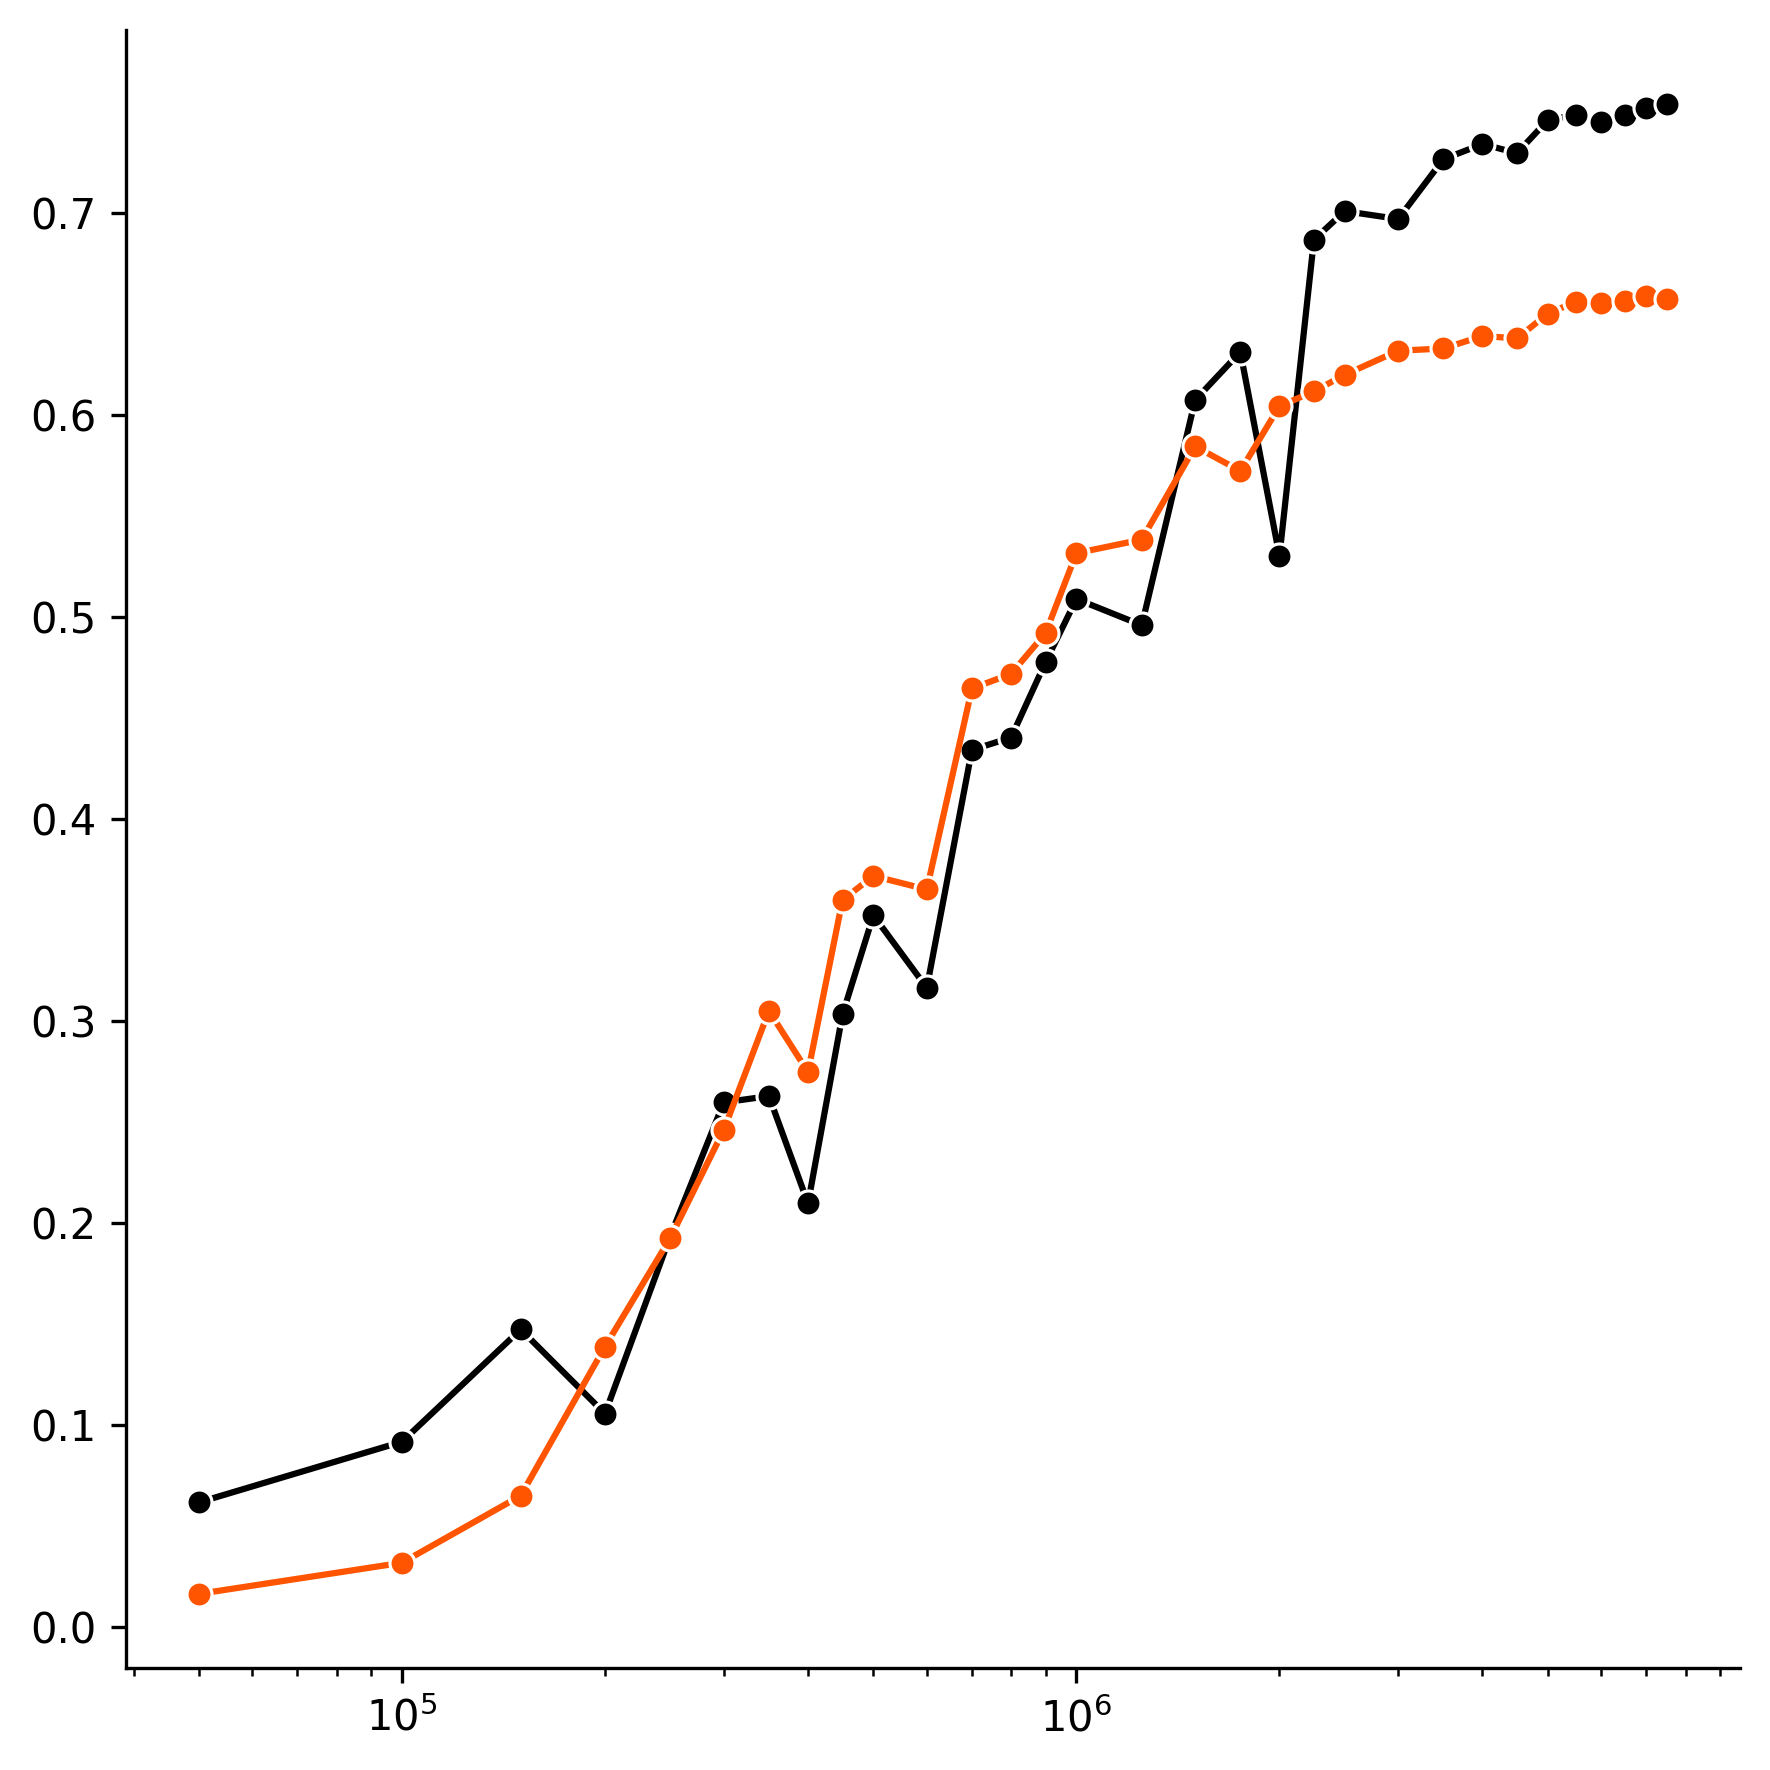

In [5]:
# First model: ResNet
model_label = "lr0.001_resnet_baselineTrue"
folder_path = f"{BACKPROP_TRAINING_PATH}/{model_label}"
subfolders = [f for f in os.listdir(folder_path) if f.startswith("checkpoint-")]
ckpt_epochs = sorted([int(f.split("-")[-1]) for f in subfolders])
accuracies = [load_acc(model_label, epoch) for epoch in ckpt_epochs]
training_samples = [(epoch / 391) * 50_000 for epoch in ckpt_epochs]

# Second model: Random scattering network
model_label2 = "lr0.001_randomTrue_staticNormTrue_10kRand_sys_freezeBefore1"
folder_path2 = f"{BACKPROP_TRAINING_PATH}/{model_label2}"
subfolders2 = [f for f in os.listdir(folder_path2) if f.startswith("checkpoint-")]
ckpt_epochs2 = sorted([int(f.split("-")[-1]) for f in subfolders2])
accuracies2 = [load_acc(model_label2, epoch) for epoch in ckpt_epochs2]
training_samples2 = [(epoch / 391) * 50_000 for epoch in ckpt_epochs2]

# Build a DataFrame for seaborn
df = pd.DataFrame({
    "training_samples": training_samples + training_samples2,
    "accuracy": accuracies + accuracies2,
    "model": ["ResNet"] * len(training_samples) + ["Random scattering"] * len(training_samples2)
})

# Create the relplot
g = sns.relplot(
    data=df,
    x="training_samples",
    y="accuracy",
    hue="model",
    kind="line",
    marker="o",
    errorbar=None,            # No error bars in this case
    height=6,
    aspect=1,
    palette={"ResNet": "k", "Random scattering": scattering_color},
)

# Use a log scale on the x-axis
g.set(xscale="log")
g.fig.set_size_inches(6, 6)  
g._legend.remove()
g.figure.set_dpi(300)

# Relabel axes
plt.xlabel("")
plt.ylabel("")

plt.tight_layout()
plt.show()
